<a href="https://colab.research.google.com/github/rajeshk9999/NLP/blob/main/FeedForwardNeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[***CS6910 - Assignment 1***](https://wandb.ai/cs6910_2024_mk/A1/reports/CS6910-Assignment-1--Vmlldzo2ODQ1ODYy)

In [ ]:
from google.colab import userdata
import os
import wandb

os.environ["wandb"] = userdata.get("wandb")
wandb.login()

True

In [ ]:
wandb.init(
    project="FeedForwardNeuralNetwork",
    name="first-run"
)

**Download the fashion-MNIST dataset and plot 1 sample image for each class as shown in the grid below. Use from keras.datasets import fashion_mnist for getting the fashion mnist dataset.**

In [1]:
import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
import random
import torch

In [2]:
from keras.datasets import fashion_mnist

In [6]:
((X_train,y_train,),(X_test,y_test))= fashion_mnist.load_data()


# **Print unique lable with one example**

In [7]:
unique_samples = {}
label= list(set(y_test))

for i in range(len(X_test)):
  if len(label) == 0:
    break

  if y_test[i] in label:
    unique_samples[y_test[i]] = X_test[i]
    label.remove(y_test[i])


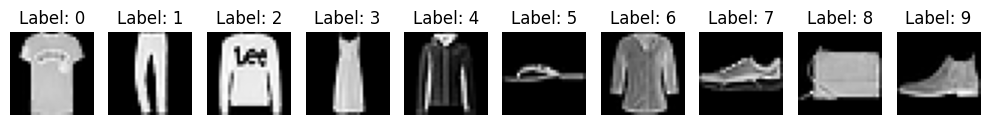

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i, (label, image) in enumerate(sorted(unique_samples.items())):
    plt.subplot(1, 10, i + 1)  # 2 rows, 5 columns, position i+1
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Flatten all the inputs into one-d**

In [9]:
X_train = X_train.reshape(X_train.shape[0], -1)            # each with 28*28 of size
X_test = X_test.reshape(X_test.shape[0],-1)
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


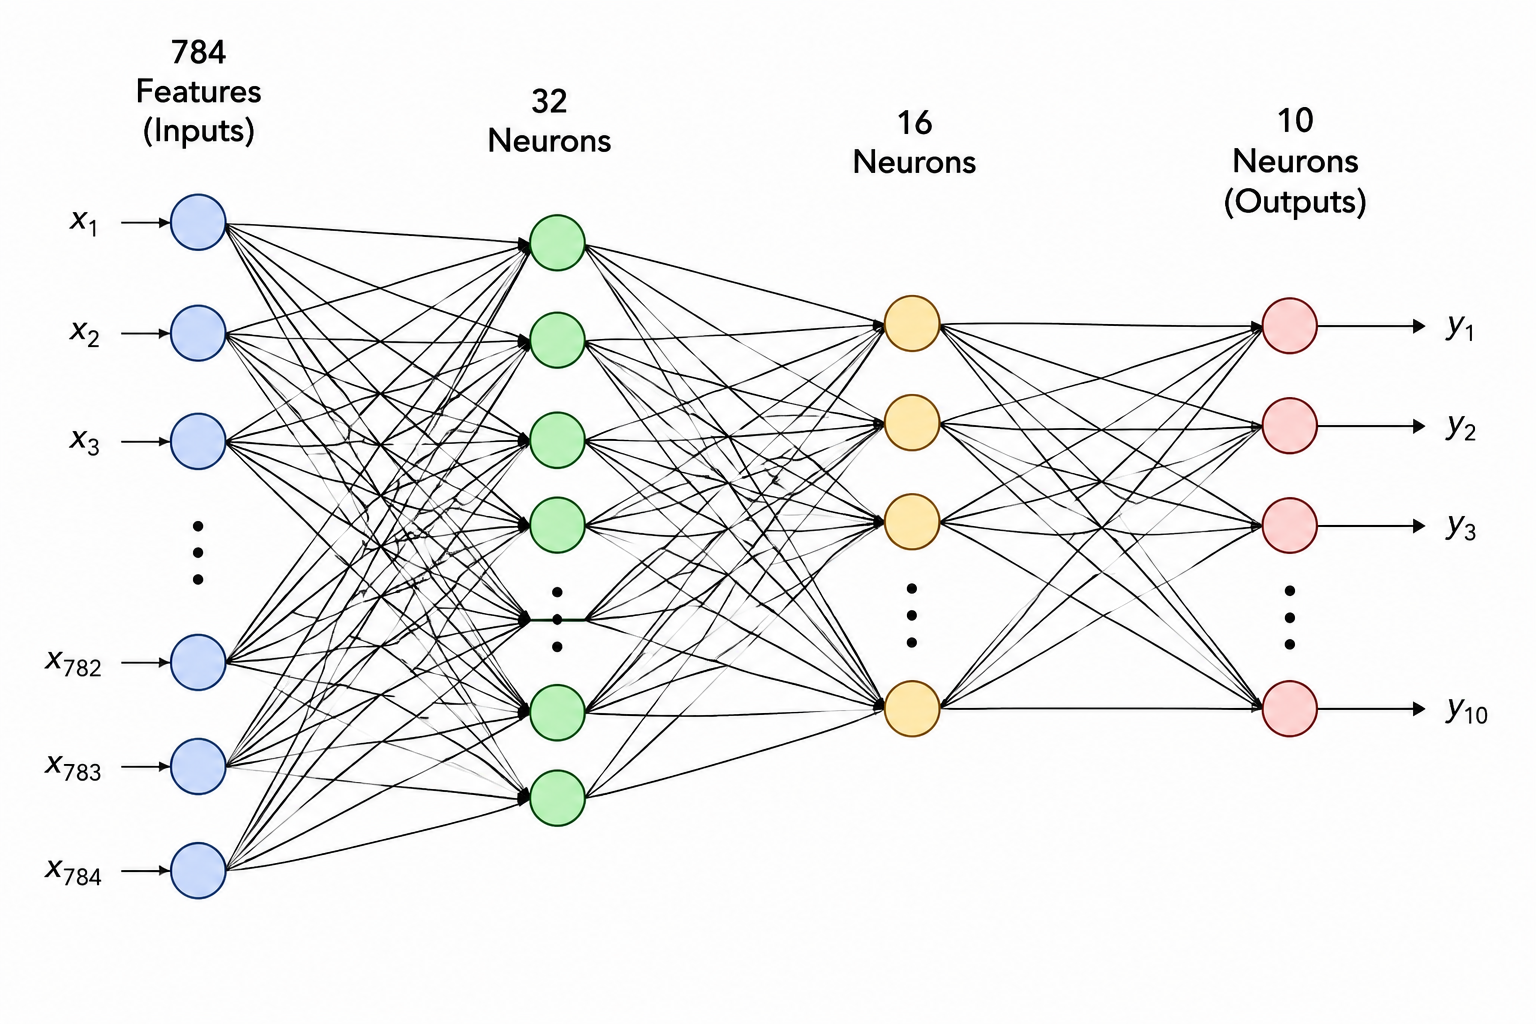

In [150]:
class FFNN:
  def __init__(self,network,X_train,y_train,X_test,y_test):      # network = [x,y,z]     3 layered network with x,y,z neurons in layer 1,2,3 respectively
    self.X_train = X_train
    self.y_train = y_train
    self.X_test = X_test
    self.y_test = y_test
    self.network = network
    self.network.append(len(set(y_train)))       # force last layer to 10 neurons
    self.nl = len(network)
    self.W = []
    self.B = []
    self.H = []
    self.G = []
    self.YP = []

  def help(self):
    print("To build Network use")
    print("FFNN() ,accepts a list containing number of layers and numbers of neurons in sequence")
    print("Example: ")
    print("FFNN([10,11,12])")
    print("number of layers = 3")
    print("layer_1 : 10 neurons , layer_2 : 11 , layer_3 : 12 neurons ")
    print("Default Layer (output layer) has 10 neurons")
    print("To know more ")
    print("1.Know all the activation functions available")
    print("2.Know available optimisation techniques")


  def init_weights(self):
    network = list.copy(self.network)
    network.insert(0,784)
    for i in range(self.nl):
      Wi=[]
      for _ in range(self.network[i]):
        Wi.append([random.random() for _ in range(network[i])])
      self.W.append(Wi)

  def init_bias(self):
    for i in range(self.nl):
          self.B.append([random.random() for _ in range(self.network[i])])


  def activation_function(self,choice,z):
    match choice:
      case "sigmoid":
        return 1/(1 + np.exp(-z))
      case "relu":
        return max(0,z)

  def forward_pass(self,batch_size,af):
    for layer in range(self.nl):
      hi = []
      for i in range(self.network[layer]):
        s = 0
        for j in range(len(self.W[layer][0])):
          s = s+self.W[layer][i][j] * X_train[batch_size][j]
        s = s+ self.B[layer][i]
        if layer != self.nl - 1 :
          s = self.activation_function(af,s)   # activation function
        hi.append(s)
      self.H.append(hi)
    if layer == self.nl:
      den = np.exp(sum(hi))
      for i in range(self.network[layer]):      # output activation function
        hi[i] = np.exp(hi[i]) / den


  def back_propagation(self,choice):



  def build_network(self):
    self.init_weights()
    self.init_bias()
    self.forward_pass(0,"sigmoid")



In [150]:
sgd
momentum based gradient descent
nesterov accelerated gradient descent
rmsprop
adam
nadam

In [151]:
f = FFNN([32,16],X_train,y_train,X_test,y_test)
f.build_network()

In [152]:
f.H

[[np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0)],
 [np.float64(0.5874014712403),
  np.float64(0.6230083063819778),
  np.float64(0.5909705832297846),
  np.float64(0.7131714227658587),
  np.float64(0.5061110508293319),
  np.float64(0.5010641662573484),
  np.float64(0.5379463961666224),
  np.float64(0.545380361952821),
  np.float64(0.6199216725330353),
  np.float64(0.6630935794633842),
  np.float64(0.6528634509062282),
  np.float64(0.630169